# Diabetes Prediction Model (BRFSS 2021)

In [14]:
# Import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Random Forest Regressor
from sklearn.ensemble import RandomForestClassifier

# For Feature Scaling
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_val_score
from skopt import BayesSearchCV

from sklearn.metrics import make_scorer, f1_score

In [4]:
# Import data
data = pd.read_csv('diabetes_binary_health_indicators_BRFSS2021.csv')
data.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0,1.0,1,15.0,1.0,0.0,0.0,0,1,...,1,0.0,5.0,10.0,20.0,0.0,0,11,4.0,5.0
1,1.0,1,0.0,1,28.0,0.0,0.0,1.0,0,1,...,1,0.0,2.0,0.0,0.0,0.0,0,11,4.0,3.0
2,1.0,1,1.0,1,33.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,10.0,0.0,0.0,0,9,4.0,7.0
3,1.0,0,1.0,1,29.0,0.0,1.0,1.0,1,1,...,1,0.0,5.0,0.0,30.0,1.0,1,12,3.0,4.0
4,0.0,0,0.0,1,24.0,1.0,0.0,0.0,0,0,...,1,0.0,3.0,0.0,0.0,1.0,1,13,5.0,6.0


In [66]:
print(df.describe())


       Diabetes_binary         HighBP       HighChol            BMI  \
count     223243.00000  223243.000000  223243.000000  223243.000000   
mean           0.14959       0.431642       0.410812      29.134414   
std            0.35667       0.495306       0.491982       6.646068   
min            0.00000       0.000000       0.000000      12.000000   
25%            0.00000       0.000000       0.000000      25.000000   
50%            0.00000       0.000000       0.000000      28.000000   
75%            0.00000       1.000000       1.000000      32.000000   
max            1.00000       1.000000       1.000000      99.000000   

              Smoker         Stroke  HeartDiseaseorAttack   PhysActivity  \
count  223243.000000  223243.000000         223243.000000  223243.000000   
mean        0.426213       0.041175              0.091174       0.766864   
std         0.494527       0.198695              0.287857       0.422829   
min         0.000000       0.000000              0.00000

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236378 entries, 0 to 236377
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       236378 non-null  float64
 1   HighBP                236378 non-null  int64  
 2   HighChol              236378 non-null  float64
 3   CholCheck             236378 non-null  int64  
 4   BMI                   236378 non-null  float64
 5   Smoker                236378 non-null  float64
 6   Stroke                236378 non-null  float64
 7   HeartDiseaseorAttack  236378 non-null  float64
 8   PhysActivity          236378 non-null  int64  
 9   Fruits                236378 non-null  int64  
 10  Veggies               236378 non-null  int64  
 11  HvyAlcoholConsump     236378 non-null  int64  
 12  AnyHealthcare         236378 non-null  int64  
 13  NoDocbcCost           236378 non-null  float64
 14  GenHlth               236378 non-null  float64
 15  

In [11]:
# Check duplicates and NA values
print(f'Number of NA values: {data.isna().sum().sum()}')
print(f'Number of duplicate records: {data.duplicated().sum()}')

Number of NA values: 0
Number of duplicate records: 13135


## Check target variable

In [15]:
# Look at the proportions
print(data['Diabetes_binary'].value_counts())
print(data['Diabetes_binary'].value_counts(normalize=True))

Diabetes_binary
0.0    202810
1.0     33568
Name: count, dtype: int64
Diabetes_binary
0.0    0.85799
1.0    0.14201
Name: proportion, dtype: float64


In [6]:
# Copy data for no duplicates
data_nodup = data.copy()

In [7]:
data_nodup = data_nodup.drop_duplicates()

In [8]:
print(data_nodup['Diabetes_binary'].value_counts())
print(data_nodup['Diabetes_binary'].value_counts(normalize=True))


Diabetes_binary
0.0    189848
1.0     33395
Name: count, dtype: int64
Diabetes_binary
0.0    0.85041
1.0    0.14959
Name: proportion, dtype: float64


## Run RF Model

In [ ]:
df = data_nodup.copy()

In [29]:
# Exclude columns

features_exclude = ["Sex", "Education", "Income", "NoDocbcCost", "AnyHealthcare", "Fruits", "Veggies", "CholCheck"]
df = df.drop(columns=features_exclude)


In [30]:
X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  
    random_state=33, 
    stratify=y
)

# Final shapes
print(f'Shape of X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'Shape of X_test: {X_test.shape}, y_test: {y_test.shape}')
print(y_train.value_counts(normalize = True))
print(y_test.value_counts(normalize = True))


Shape of X_train: (178594, 13), y_train: (178594,)
Shape of X_test: (44649, 13), y_test: (44649,)
Diabetes_binary
0.0    0.850409
1.0    0.149591
Name: proportion, dtype: float64
Diabetes_binary
0.0    0.850411
1.0    0.149589
Name: proportion, dtype: float64


In [31]:
# Define the search space for hyperparameters
search_space = {
    'n_estimators': (100, 300),  # Integer range for n_estimators
    'max_depth': (1, 40),  # Integer range for max_depth
    'min_samples_split': (2, 20),  # Integer range for min_samples_split
    'min_samples_leaf': (1, 20),  # Integer range for min_samples_leaf
    'max_features': ['sqrt', 'log2', None],  # Choice of max_features 
}

# Initialize the Random Forest model
rf = RandomForestClassifier(random_state=33, class_weight='balanced')


from sklearn.metrics import make_scorer, f1_score

# Define F1 score as the scoring metric
f1_scorer = make_scorer(f1_score)


# Perform Bayesian optimization with 5-fold cross-validation
opt = BayesSearchCV(
    rf,
    search_space,
    n_iter=20,  # Number of iterations
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all available cores
    scoring = f1_scorer,
    random_state=33,
    verbose=1
)

# Fit the model with hyperparameter tuning
opt.fit(X_train, y_train)
print("Best Parameters found: ", opt.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [ ]:
# For all features
# {'max_depth': 21, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 14, 'n_estimators': 260}
best_rf_model = RandomForestClassifier(
    n_estimators=260
    , max_depth=21
    , max_features='sqrt'
    , min_samples_leaf=5
    , min_samples_split=14
    , class_weight='balanced'
    , random_state=33
)

In [32]:
# For selected features

# {'max_depth': 18, 'max_features': 'sqrt', 'min_samples_leaf': 15, 'min_samples_split': 12, 'n_estimators': 227}
best_rf_model = RandomForestClassifier(
    n_estimators=227
    , max_depth=18
    , max_features='sqrt'
    , min_samples_leaf=15
    , min_samples_split=12
    , class_weight='balanced'
    , random_state=33
)

#### Fit best rf model

In [47]:
#Reorder the columns
new_feature_order = ['Age', 'BMI'] + [feature for feature in ['HighBP', 'HighChol', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump',
       'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk'] if feature not in ['Age', 'BMI']]

print("New Feature Order:", new_feature_order)

New Feature Order: ['Age', 'BMI', 'HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']


In [50]:
X_train = X_train[new_feature_order]
X_test = X_test[new_feature_order]

In [51]:
best_rf_model.fit(X_train,y_train)
y_preds_train = best_rf_model.predict(X_train)
y_preds_test = best_rf_model.predict(X_test)

In [54]:
print(f'Training F1 Score: {f1_score(y_train,y_preds_train)}')
print(f'Testing F1 Score: {f1_score(y_test,y_preds_test)}')

Training F1 Score: 0.47982450157994044
Testing F1 Score: 0.4491725768321513


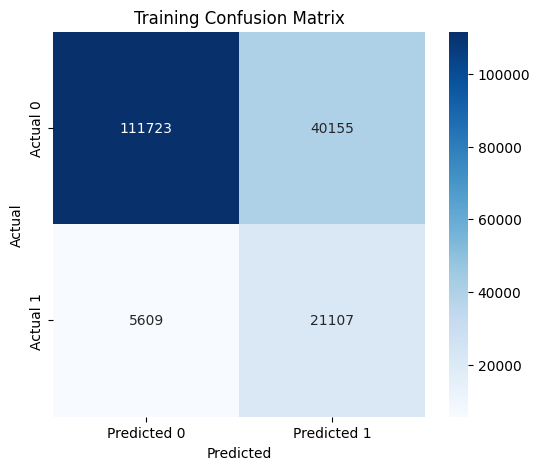

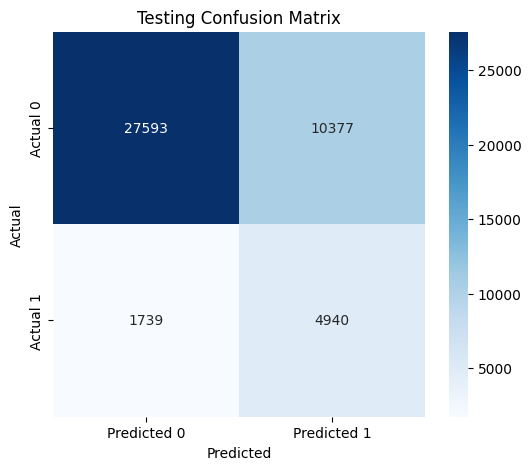

In [55]:
from sklearn.metrics import confusion_matrix, f1_score
# Confusion matrix for training data
cm_train = confusion_matrix(y_train, y_preds_train)

# Confusion matrix for testing data
cm_test = confusion_matrix(y_test, y_preds_test)

import seaborn as sns
import matplotlib.pyplot as plt

# Function to plot confusion matrix
def plot_confusion_matrix(cm, title='Confusion Matrix'):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Plot confusion matrix for training data
plot_confusion_matrix(cm_train, title='Training Confusion Matrix')

# Plot confusion matrix for testing data
plot_confusion_matrix(cm_test, title='Testing Confusion Matrix')


In [56]:
from sklearn.metrics import classification_report

# Classification report for training data
print("Classification Report - Training Data:")
print(classification_report(y_train, y_preds_train))

# Classification report for testing data
print("Classification Report - Testing Data:")
print(classification_report(y_test, y_preds_test))

Classification Report - Training Data:
              precision    recall  f1-score   support

         0.0       0.95      0.74      0.83    151878
         1.0       0.34      0.79      0.48     26716

    accuracy                           0.74    178594
   macro avg       0.65      0.76      0.65    178594
weighted avg       0.86      0.74      0.78    178594

Classification Report - Testing Data:
              precision    recall  f1-score   support

         0.0       0.94      0.73      0.82     37970
         1.0       0.32      0.74      0.45      6679

    accuracy                           0.73     44649
   macro avg       0.63      0.73      0.63     44649
weighted avg       0.85      0.73      0.76     44649



### Obtain probability

In [57]:
# Predict on training and testing data
# Predict probabilities
y_probs_train = best_rf_model.predict_proba(X_train)[:, 1]  # Probability for class 1
y_probs_test = best_rf_model.predict_proba(X_test)[:, 1]    # Probability for class 1

In [19]:
print("Sample predicted probabilities for training data (class 1):")
print(y_probs_train[:10])  # Print first 10 probabilities for training

print("Sample predicted probabilities for testing data (class 1):")
print(y_probs_test[:10])  # Print first 10 probabilities for testing

Sample predicted probabilities for training data (class 1):
[0.2514172  0.50500828 0.13655092 0.02547998 0.56024119 0.26596745
 0.56435205 0.01969335 0.73389006 0.2448789 ]
Sample predicted probabilities for testing data (class 1):
[0.19101484 0.06539599 0.1977028  0.30732162 0.01665139 0.24933067
 0.44435298 0.12226096 0.35810686 0.74923034]


In [58]:
# Create a DataFrame for predicted probabilities
probabilities_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_preds_test,
    'Probability_Positive_Class': y_probs_test
})

print(probabilities_df.head(20))

        Actual  Predicted  Probability_Positive_Class
232251     0.0        0.0                    0.258572
146457     0.0        0.0                    0.051711
194283     0.0        0.0                    0.276982
186318     0.0        0.0                    0.424884
17311      0.0        0.0                    0.024089
220479     0.0        0.0                    0.264583
204599     0.0        0.0                    0.478523
205006     0.0        0.0                    0.205595
91206      0.0        0.0                    0.465514
54262      0.0        1.0                    0.793279
210297     0.0        1.0                    0.616970
232460     0.0        0.0                    0.176771
118177     0.0        1.0                    0.674829
1584       0.0        0.0                    0.030895
39193      0.0        1.0                    0.706282
6197       1.0        1.0                    0.692769
134941     0.0        0.0                    0.044748
217880     0.0        1.0   

In [59]:
# Filter rows where the probability of the positive class is greater than 0.8
threshold = 0.8
high_probabilities_df = probabilities_df[probabilities_df['Probability_Positive_Class'] > threshold]

# Print the first 20 rows of the filtered DataFrame
print(high_probabilities_df.head(20))

        Actual  Predicted  Probability_Positive_Class
181014     1.0        1.0                    0.850382
215160     1.0        1.0                    0.873666
117306     1.0        1.0                    0.915860
48288      1.0        1.0                    0.827428
76978      1.0        1.0                    0.838701
184661     0.0        1.0                    0.846792
116498     1.0        1.0                    0.805903
183261     1.0        1.0                    0.882602
139911     0.0        1.0                    0.841209
46868      0.0        1.0                    0.803322
137608     1.0        1.0                    0.849270
234150     1.0        1.0                    0.824655
36243      1.0        1.0                    0.840124
107604     1.0        1.0                    0.911229
10518      1.0        1.0                    0.804614
222277     0.0        1.0                    0.844765
160945     1.0        1.0                    0.833955
107202     1.0        1.0   

In [61]:
feature_importances = best_rf_model.feature_importances_

# If you have a list of feature names
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importances
})

print(importance_df.sort_values(by = 'Importance', ascending = False))

                 Feature  Importance
9                GenHlth    0.207706
2                 HighBP    0.196237
0                    Age    0.165564
1                    BMI    0.138763
3               HighChol    0.083469
11              PhysHlth    0.044090
12              DiffWalk    0.043575
10              MentHlth    0.038382
6   HeartDiseaseorAttack    0.028930
7           PhysActivity    0.022600
8      HvyAlcoholConsump    0.013624
4                 Smoker    0.012480
5                 Stroke    0.004581


In [62]:
best_rf_model.feature_names_in_

array(['Age', 'BMI', 'HighBP', 'HighChol', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump',
       'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk'], dtype=object)

Diabetes probability legend
>= 0.8 Highly likely
>= 0.5 - 0.8 You should be checked
>=

In [63]:
# Save the model
import joblib

joblib.dump(best_rf_model, "diabetes_model.joblib")


['diabetes_model.joblib']